In [1]:
import numpy as np
from os import listdir

from AutoencoderAPI.utils.decibels import file_name_table
from AutoencoderAPI.utils.correlation import second_order
from AutoencoderAPI.autoencoderKernelDensity import autoencoder_kernelDensity

In [2]:
decibel_dict= file_name_table('Datasets/NIST (800)/', 800, (67,71))

In [3]:
signal_size = 800
path_test = 'Datasets/NIST (800)/'
path_train = 'Datasets/NIST (250) train/'

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

#X = np.concatenate((X_test,X_train))

{'files': {'dataset': 'Datasets/NIST (800)', 'path_save': 'AutoencoderLog/', 'input_dimension': 800}, 'network': {'network_type': 'generic', 'activation_list': ['Mish', 'CELU', 'Tanh', 'CELU', 'Mish'], 'layer_list': [800, 50, 50, 1, 50, 50, 800], 'layer_type': 'Linear'}, 'train': {'optimizer': 'Adam', 'criterion': 'MSELoss', 'k-fold': 2, 'batch_number': 1, 'epochs': 10, 'skip_elements': 1, 'learning_rate': 1e-05}, 'internal': {'device': device(type='cpu')}}


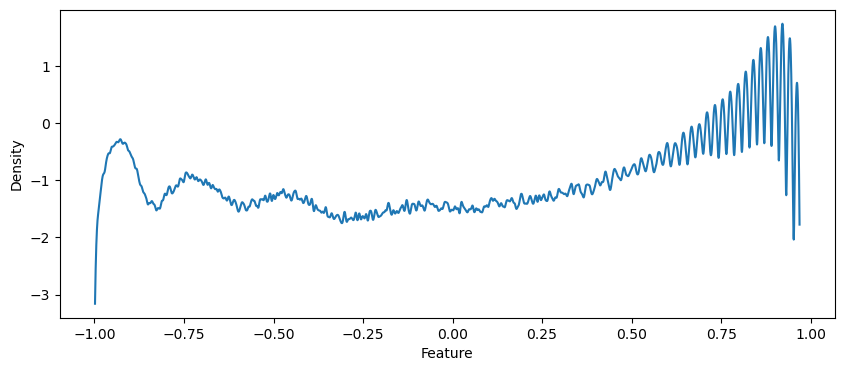

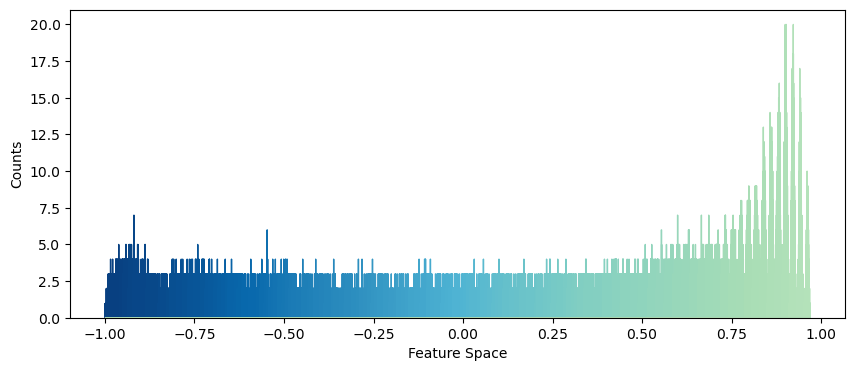

In [4]:
ak = autoencoder_kernelDensity("AutoencoderLog/run-2023-10-05-22-04/fold 0")
ak.fit(X[::2], plot_cluster=True, plot_traces=False, plot_density=True, bw_cst=[0.0025], flip=True)

In [5]:
decibel = []
g2 = []
average = []
labels = []
for key in decibel_dict.keys():
    X = decibel_dict[key]
    labels_ = ak.get_label_filter(X)
    labels = np.append(labels, labels_)
    decibel.append(float(key))
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

In [6]:
decibel

[23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0]

In [7]:
g2

[1.0167216463023947,
 1.0793062125912636,
 1.036069451912253,
 1.015901822468611,
 1.0014811115464166,
 0.9937139305505643,
 0.9924006165477195,
 0.9922695378948813,
 0.9922291374383161,
 0.9921864681434219,
 0.9921884921446756,
 0.9921931431606864,
 0.9921856819086271]

In [8]:
average

[3.4627652563595626,
 15.907046903460838,
 39.38086206896552,
 67.24264874798989,
 90.73250043785393,
 104.93279305354558,
 112.03466840205881,
 116.6951441026883,
 120.0366176380085,
 122.19804965676525,
 123.9776913761234,
 125.15531747075063,
 125.99699679658302]

In [9]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB * cst)

def function1(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * np.exp(-dB - cst)

[1.23472935e+02 2.27697948e-23]


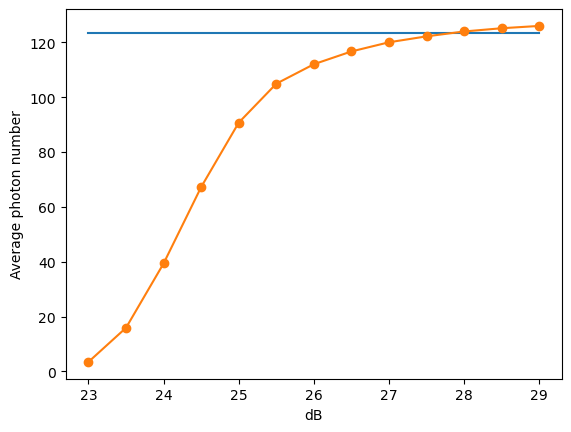

In [10]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

popt, pcov = curve_fit(function, decibel[-5:], average[-5:], 
                       bounds=([0, 0], [1e14, 10]),
                       p0=[4,0.1])
plt.plot(decibel, function(decibel, *popt))
plt.plot(decibel, average,marker='o' )
#plt.yscale("log")
plt.xlabel("dB")
plt.ylabel("Average photon number")
print(popt)

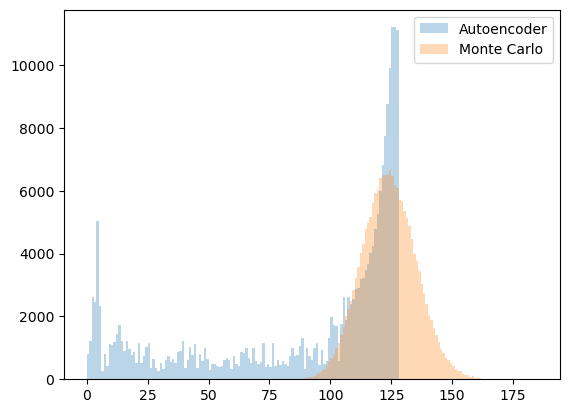

In [11]:
import numpy.random as npr

decibel = np.arange(23,29.5,0.5)
average = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 14_000) for i in average])
plt.hist(labels, alpha=0.3, bins=np.unique(labels), label='Autoencoder')
plt.hist(n, alpha=0.3, bins=np.unique(n), label='Monte Carlo')
plt.legend()
plt.show()